In [1]:
import prettytable
import csv, sqlite3
import pandas as pd

prettytable.DEFAULT = 'DEFAULT'

con = sqlite3.connect("FinalDB.db")
cur = con.cursor()

%load_ext sql
# Connect to the database
%sql sqlite:///FinalDB.db

df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DB0201EN-SkillsNetwork/labs/FinalModule_Coursera_V5/data/ChicagoCensusData.csv?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDB0201ENSkillsNetwork20127838-2021-01-01")
df.to_sql("CENSUS_DATA", con, if_exists='replace', index=False)

df2 = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DB0201EN-SkillsNetwork/labs/FinalModule_Coursera_V5/data/ChicagoPublicSchools.csv?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDB0201ENSkillsNetwork20127838-2021-01-01")
df2.to_sql("CHICAGO_PUBLIC_SCHOOLS", con, if_exists='replace', index=False)

df3 = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DB0201EN-SkillsNetwork/labs/FinalModule_Coursera_V5/data/ChicagoCrimeData.csv?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDB0201ENSkillsNetwork20127838-2021-01-01")
df3.to_sql("CHICAGO_CRIME_DATA", con, if_exists='replace', index=False)


533

In [3]:
%sql SELECT name FROM sqlite_master WHERE type='table'

 * sqlite:///FinalDB.db
Done.


name
CENSUS_DATA
CHICAGO_PUBLIC_SCHOOLS
CHICAGO_CRIME_DATA


### Questions to answer

##### 1. What is the total number of crimes recorded in the CRIME table?

In [4]:
%sql SELECT COUNT(*) FROM CHICAGO_CRIME_DATA;

 * sqlite:///FinalDB.db
Done.


COUNT(*)
533


##### 2. List community area names and numbers with per capita income less than 11000.

In [5]:
%sql SELECT community_area_number, community_area_name FROM CENSUS_DATA WHERE per_capita_income < 11000;

 * sqlite:///FinalDB.db
Done.


COMMUNITY_AREA_NUMBER,COMMUNITY_AREA_NAME
26.0,West Garfield Park
30.0,South Lawndale
37.0,Fuller Park
54.0,Riverdale


##### 3. List all case numbers for crimes involving minors?(children are not considered minors for the purposes of crime analysis)

In [19]:
%sql SELECT * FROM CHICAGO_CRIME_DATA WHERE DESCRIPTION LIKE '%MINOR%';

 * sqlite:///FinalDB.db
Done.


ID,CASE_NUMBER,DATE,BLOCK,IUCR,PRIMARY_TYPE,DESCRIPTION,LOCATION_DESCRIPTION,ARREST,DOMESTIC,BEAT,DISTRICT,WARD,COMMUNITY_AREA_NUMBER,FBICODE,X_COORDINATE,Y_COORDINATE,YEAR,LATITUDE,LONGITUDE,LOCATION
3987219,HL266884,2005-03-31,024XX N CLARK ST,2210,LIQUOR LAW VIOLATION,SELL/GIVE/DEL LIQUOR TO MINOR,CONVENIENCE STORE,1,0,2333,19,43.0,7.0,22,1172680.0,1916483.0,2005,41.92626872,-87.64089934,"(41.926268719, -87.640899336)"
3266814,HK238408,2004-03-13,093XX S STONY ISLAND AVE,2230,LIQUOR LAW VIOLATION,ILLEGAL CONSUMPTION BY MINOR,ALLEY,1,0,413,4,8.0,48.0,22,1188539.0,1843379.0,2004,41.72530099,-87.58496589,"(41.72530099, -87.584965887)"


##### 4. List all kidnapping crimes involving a child

In [18]:
%sql SELECT * FROM CHICAGO_CRIME_DATA WHERE DESCRIPTION LIKE '%CHILD%' AND PRIMARY_TYPE = 'KIDNAPPING';

 * sqlite:///FinalDB.db
Done.


ID,CASE_NUMBER,DATE,BLOCK,IUCR,PRIMARY_TYPE,DESCRIPTION,LOCATION_DESCRIPTION,ARREST,DOMESTIC,BEAT,DISTRICT,WARD,COMMUNITY_AREA_NUMBER,FBICODE,X_COORDINATE,Y_COORDINATE,YEAR,LATITUDE,LONGITUDE,LOCATION
5276766,HN144152,2007-01-26,050XX W VAN BUREN ST,1792,KIDNAPPING,CHILD ABDUCTION/STRANGER,STREET,0,0,1533,15,29.0,25.0,20,1143050.0,1897546.0,2007,41.87490841,-87.75024931,"(41.874908413, -87.750249307)"


##### 5. List the kind of crimes that were recorded at schools. (No repetitions)

In [32]:
%sql SELECT DISTINCT PRIMARY_TYPE AS 'KIND OF CRIME' FROM CHICAGO_CRIME_DATA WHERE LOCATION_DESCRIPTION LIKE '%SCHOOL%';

 * sqlite:///FinalDB.db
Done.


KIND OF CRIME
BATTERY
CRIMINAL DAMAGE
NARCOTICS
ASSAULT
CRIMINAL TRESPASS
PUBLIC PEACE VIOLATION


##### 6. List the type of schools along with the average safety score for each type.

In [67]:
%sql SELECT [Elementary, Middle, or High School], AVG(SAFETY_SCORE) FROM CHICAGO_PUBLIC_SCHOOLS GROUP BY [Elementary, Middle, or High School];

 * sqlite:///FinalDB.db
Done.


"Elementary, Middle, or High School",AVG(SAFETY_SCORE)
ES,49.52038369304557
HS,49.62352941176471
MS,48.0


##### 7. List 5 community areas with highest % of households below poverty line

In [58]:
%sql SELECT COMMUNITY_AREA_NAME, PERCENT_HOUSEHOLDS_BELOW_POVERTY FROM CENSUS_DATA ORDER BY PERCENT_HOUSEHOLDS_BELOW_POVERTY DESC LIMIT 5;

 * sqlite:///FinalDB.db
Done.


COMMUNITY_AREA_NAME,PERCENT_HOUSEHOLDS_BELOW_POVERTY
Riverdale,56.5
Fuller Park,51.2
Englewood,46.6
North Lawndale,43.1
East Garfield Park,42.4


##### 8. Which community area is most crime prone? Display the coumminty area number only.

In [63]:
%sql SELECT COMMUNITY_AREA_NUMBER, COUNT(*) FROM CHICAGO_CRIME_DATA GROUP BY COMMUNITY_AREA_NUMBER ORDER BY COUNT(*) DESC LIMIT 1;

 * sqlite:///FinalDB.db
Done.


COMMUNITY_AREA_NUMBER,COUNT(*)
25.0,43


##### 9. Use a sub-query to find the name of the community area with highest hardship index

In [65]:
%sql SELECT COMMUNITY_AREA_NAME FROM CENSUS_DATA WHERE HARDSHIP_INDEX = (SELECT MAX(HARDSHIP_INDEX) FROM CENSUS_DATA);

 * sqlite:///FinalDB.db
Done.


COMMUNITY_AREA_NAME
Riverdale


##### 10. Use a sub-query to determine the Community Area Name with most number of crimes?

In [66]:
%sql SELECT COMMUNITY_AREA_NAME FROM CENSUS_DATA WHERE COMMUNITY_AREA_NUMBER = (SELECT COMMUNITY_AREA_NUMBER FROM CHICAGO_CRIME_DATA WHERE COMMUNITY_AREA_NUMBER = 25);

 * sqlite:///FinalDB.db
Done.


COMMUNITY_AREA_NAME
Austin


### Queries and Graphics

In [6]:
%%sql result <<
SELECT
    COMMUNITY_AREA_NAME,
    HARDSHIP_INDEX,
    PERCENT_AGED_25__WITHOUT_HIGH_SCHOOL_DIPLOMA,
    PERCENT_HOUSEHOLDS_BELOW_POVERTY
FROM CENSUS_DATA
WHERE HARDSHIP_INDEX IS NOT NULL;

 * sqlite:///FinalDB.db
Done.
Returning data to local variable result


In [7]:
df_analysis = result.DataFrame()
df_analysis.head()

,COMMUNITY_AREA_NAME,HARDSHIP_INDEX,PERCENT_AGED_25__WITHOUT_HIGH_SCHOOL_DIPLOMA,PERCENT_HOUSEHOLDS_BELOW_POVERTY
0,Rogers Park,39.0,18.2,23.6
1,West Ridge,46.0,20.8,17.2
2,Uptown,20.0,11.8,24.0
3,Lincoln Square,17.0,13.4,10.9
4,North Center,6.0,4.5,7.5


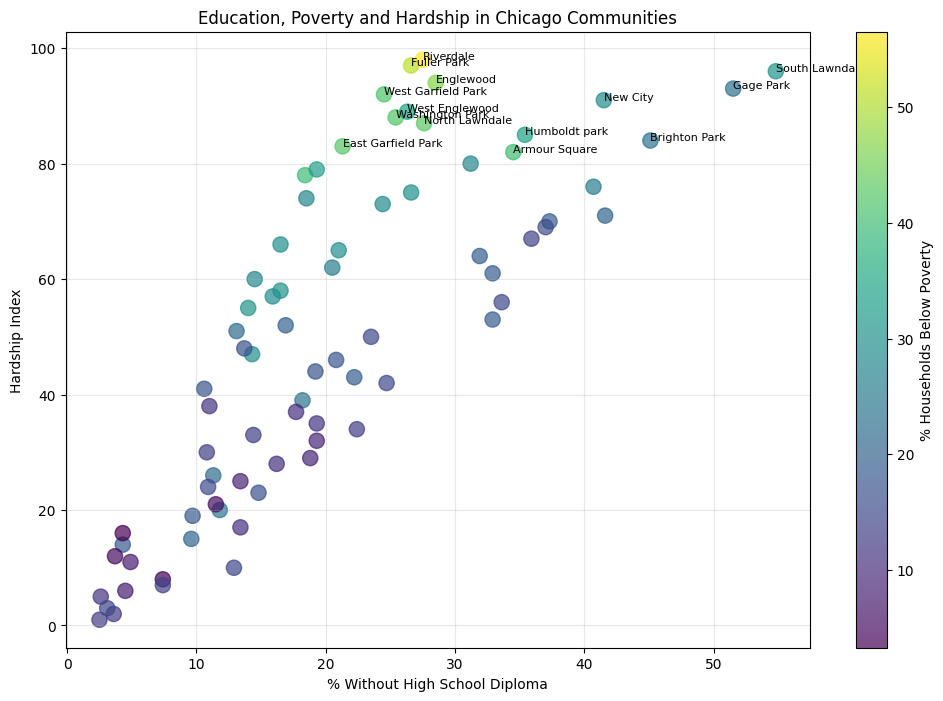

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

scatter = plt.scatter(
    df_analysis['PERCENT_AGED_25__WITHOUT_HIGH_SCHOOL_DIPLOMA'],
    df_analysis['HARDSHIP_INDEX'],
    c=df_analysis['PERCENT_HOUSEHOLDS_BELOW_POVERTY'],
    s=120,
    alpha=0.7
)

plt.xlabel('% Without High School Diploma')
plt.ylabel('Hardship Index')

plt.title(
    'Education, Poverty and Hardship in Chicago Communities'
)

cbar = plt.colorbar(scatter)
cbar.set_label('% Households Below Poverty')

plt.grid(True, alpha=0.3)

for i, row in df_analysis.iterrows():
    if row['HARDSHIP_INDEX'] > 80:
        plt.text(
            row['PERCENT_AGED_25__WITHOUT_HIGH_SCHOOL_DIPLOMA'],
            row['HARDSHIP_INDEX'],
            row['COMMUNITY_AREA_NAME'],
            fontsize=8
        )
        
plt.savefig(
    'education_vs_hardship.png',
    bbox_inches='tight'
)

plt.show()

In [14]:
%%sql resultCrimesAndCommunities <<

SELECT
    CC.PRIMARY_TYPE,
    COUNT(*) AS TOTAL_CRIMES
FROM CHICAGO_CRIME_DATA CC
JOIN CENSUS_DATA C
ON CC.COMMUNITY_AREA_NUMBER = C.COMMUNITY_AREA_NUMBER
WHERE C.HARDSHIP_INDEX > 80
GROUP BY CC.PRIMARY_TYPE
ORDER BY TOTAL_CRIMES DESC
LIMIT 10;

 * sqlite:///FinalDB.db
Done.
Returning data to local variable resultCrimesAndCommunities


In [16]:
df_crimes = resultCrimesAndCommunities.DataFrame()

df_crimes.head()

,PRIMARY_TYPE,TOTAL_CRIMES
0,BATTERY,29
1,NARCOTICS,20
2,THEFT,19
3,CRIMINAL DAMAGE,14
4,ASSAULT,9


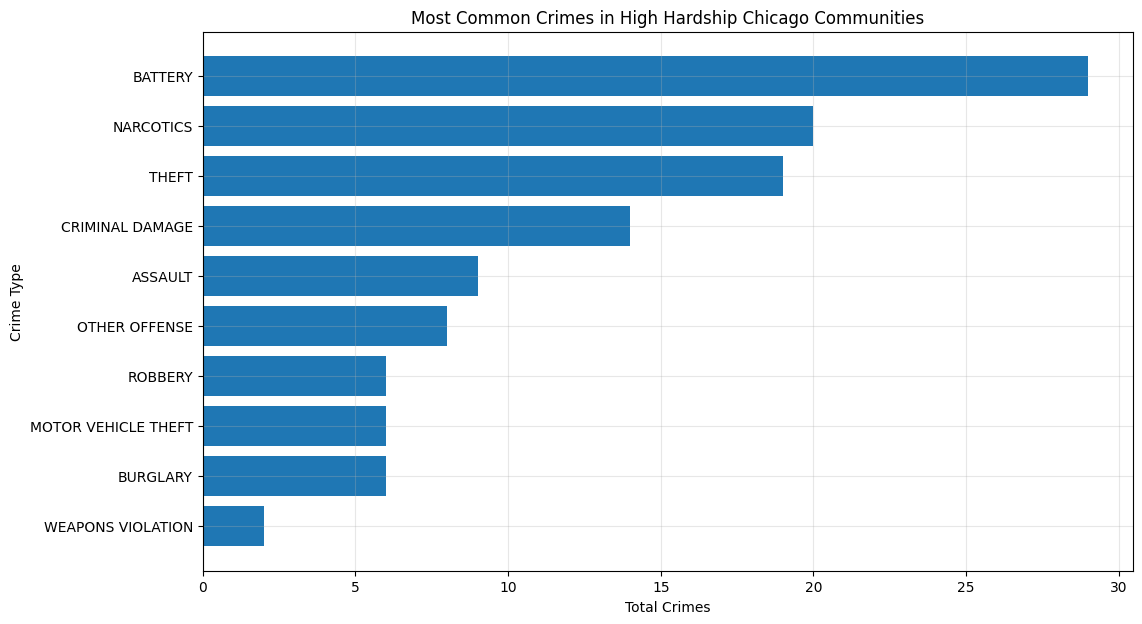

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,7))

plt.barh(
    df_crimes['PRIMARY_TYPE'],
    df_crimes['TOTAL_CRIMES']
)

plt.xlabel('Total Crimes')
plt.ylabel('Crime Type')

plt.title(
    'Most Common Crimes in High Hardship Chicago Communities'
)

plt.gca().invert_yaxis()

plt.grid(True, alpha=0.3)

plt.savefig(
    'high_hardship_crimes.png',
    bbox_inches='tight'
)

plt.show()

In [20]:
%%sql resultSchools <<

SELECT
    CPS.COMMUNITY_AREA_NAME,
    CPS.PARENT_ENGAGEMENT_SCORE,
    CPS.AVERAGE_STUDENT_ATTENDANCE,
    C.HARDSHIP_INDEX,
    COUNT(CC.CASE_NUMBER) AS TOTAL_CRIMES

FROM CHICAGO_PUBLIC_SCHOOLS CPS

JOIN CENSUS_DATA C
ON CPS.COMMUNITY_AREA_NUMBER = C.COMMUNITY_AREA_NUMBER

JOIN CHICAGO_CRIME_DATA CC
ON CPS.COMMUNITY_AREA_NUMBER = CC.COMMUNITY_AREA_NUMBER

WHERE CPS.PARENT_ENGAGEMENT_SCORE IS NOT NULL

GROUP BY
    CPS.COMMUNITY_AREA_NAME,
    CPS.PARENT_ENGAGEMENT_SCORE,
    CPS.AVERAGE_STUDENT_ATTENDANCE,
    C.HARDSHIP_INDEX;

 * sqlite:///FinalDB.db
Done.
Returning data to local variable resultSchools


In [21]:
df_school_analysis = resultSchools.DataFrame()

df_school_analysis.head()

,COMMUNITY_AREA_NAME,Parent_Engagement_Score,AVERAGE_STUDENT_ATTENDANCE,HARDSHIP_INDEX,TOTAL_CRIMES
0,ALBANY PARK,46,96.20%,53.0,5
1,ALBANY PARK,46,97.00%,53.0,5
2,ALBANY PARK,49,96.50%,53.0,5
3,ALBANY PARK,50,95.60%,53.0,5
4,ALBANY PARK,51,96.40%,53.0,5


In [25]:
df_school_analysis = df_school_analysis[
    df_school_analysis['Parent_Engagement_Score'] != 'NDA'
]

df_school_analysis['Parent_Engagement_Score'] = (
    df_school_analysis['Parent_Engagement_Score']
    .astype(float)
)

df_school_analysis['AVERAGE_STUDENT_ATTENDANCE'] = (
    df_school_analysis['AVERAGE_STUDENT_ATTENDANCE']
    .str.replace('%', '')
    .astype(float)
)

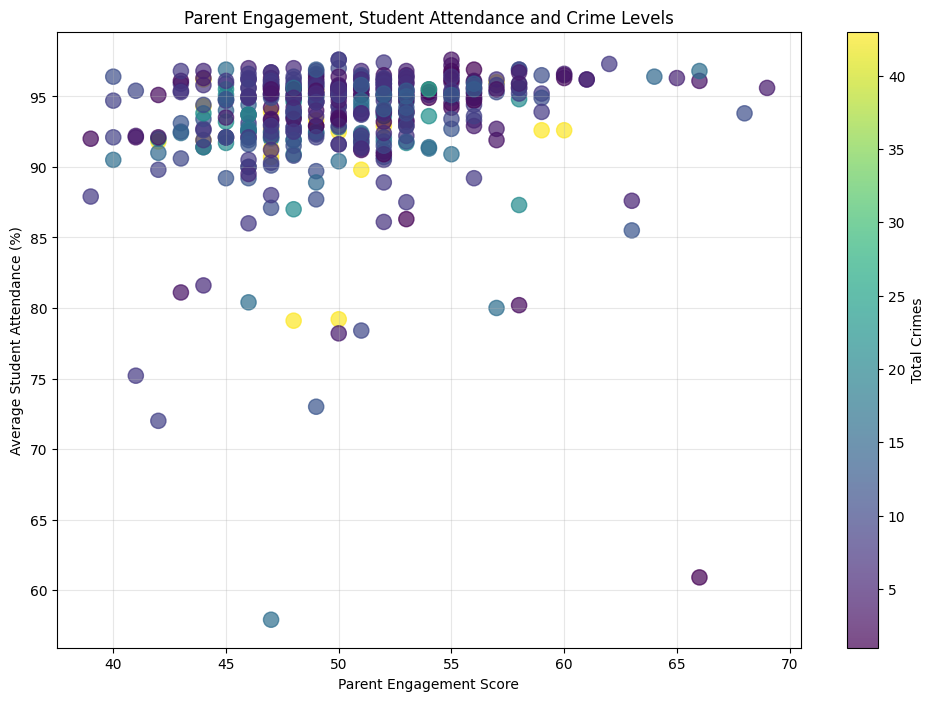

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

scatter = plt.scatter(
    df_school_analysis['Parent_Engagement_Score'],
    df_school_analysis['AVERAGE_STUDENT_ATTENDANCE'],
    c=df_school_analysis['TOTAL_CRIMES'],
    s=120,
    alpha=0.7
)

plt.xlabel('Parent Engagement Score')
plt.ylabel('Average Student Attendance (%)')

plt.title(
    'Parent Engagement, Student Attendance and Crime Levels'
)

cbar = plt.colorbar(scatter)
cbar.set_label('Total Crimes')

plt.grid(True, alpha=0.3)

for i, row in df_school_analysis.iterrows():
    if row['TOTAL_CRIMES'] > 500:
        plt.text(
            row['Parent_Engagement_Score'],
            row['AVERAGE_STUDENT_ATTENDANCE'],
            row['COMMUNITY_AREA_NAME'],
            fontsize=8
        )
        
plt.savefig(
    'school_analysis.png',
    bbox_inches='tight'
)

plt.show()